# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

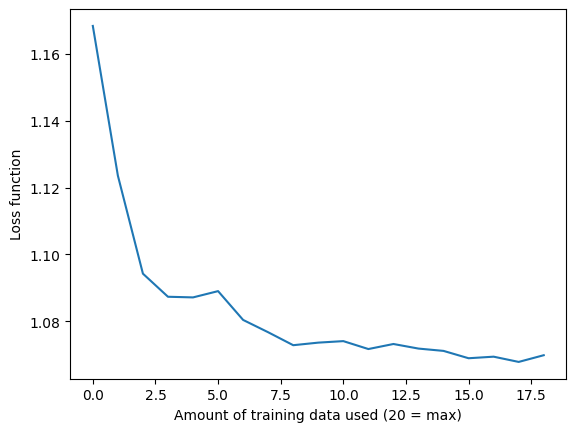

In [13]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [14]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

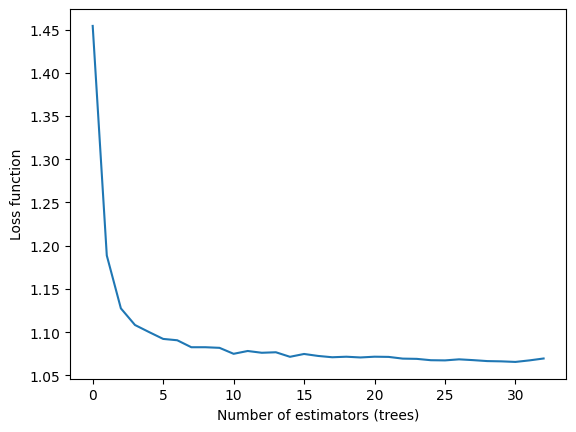

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Answer
#### If I had to cut one of the two plots, I would cut the second one - the plot showing loss as a function of the amount of training data used. While it confirms the expected pattern that more data improves performance, it offers limited practical value beyond that obvious takeaway. On the other hand, the plot showing loss as a function of the number of estimators (trees) is more interesting and useful. It shows us how the model's verall complexity affects performance and helps identify where additional trees stop yielding significant improvements - information that's directly actionable during model tuning. The number of estimators is a parameter we can control and optimize, whereas training data size is often fixed or dictated by external factors. From a model optimization standpoint, the first plot provides more insight and utility, making it the one to keep.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

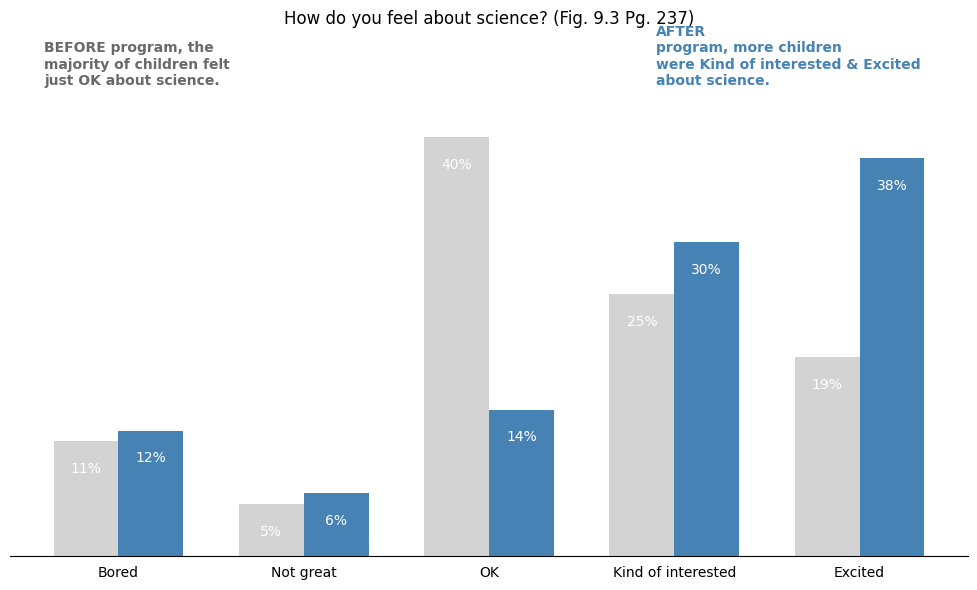

In [11]:
# figure 9.3 from page 237
# data
categories = ['Bored', 'Not great', 'OK', 'Kind of interested', 'Excited']
before = [11, 5, 40, 25, 19]
after = [12, 6, 14, 30, 38]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# add bars
bars1 = ax.bar(x - width/2, before, width, color='lightgray')
bars2 = ax.bar(x + width/2, after, width, color='steelblue')

# annotations inside bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -15),
                textcoords="offset points",
                ha='center', va='top', fontsize=10, color='white')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -15),
                textcoords="offset points",
                ha='center', va='top', fontsize=10, color='white')

# axes formatting
ax.set_title('How do you feel about science? (Fig. 9.3 Pg. 237)')
ax.set_xticks(x)
ax.set_xticklabels(categories)

# commentary
ax.text(-0.4, 45, "BEFORE program, the\nmajority of children felt\njust OK about science.", 
        fontsize=10, color='dimgray', weight='bold')

ax.text(2.9, 45, "AFTER\nprogram, more children\nwere Kind of interested & Excited\nabout science.", 
        fontsize=10, color='steelblue', weight='bold')

# remove spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(False)
ax.yaxis.set_ticks([])
ax.xaxis.set_ticks_position('none')

# no mo grid lines
ax.yaxis.grid(False)

# final layout
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()
